In [1]:
!pip uninstall -y langchain langchain-core langchain-mistralai langgraph
!pip install -qU \
    langchain \
    langchain-core \
    langchain-mistralai \
    langgraph \
    python-dotenv

Found existing installation: langchain 1.3.1
Uninstalling langchain-1.3.1:
  Successfully uninstalled langchain-1.3.1
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain-mistralai 1.1.4
Uninstalling langchain-mistralai-1.1.4:
  Successfully uninstalled langchain-mistralai-1.1.4
Found existing installation: langgraph 1.2.1
Uninstalling langgraph-1.2.1:
  Successfully uninstalled langgraph-1.2.1


In [2]:
!pip install -qU langchain langchain-core langchain-mistralai langgraph python-dotenv

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
from google.colab import userdata
import os

# Load secret from Colab Secrets
os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")

In [5]:
load_dotenv()

llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0
)

response = llm.invoke("Explain LangGraph in one sentence")
print(response.content)

**LangGraph** is a framework for building stateful, multi-actor AI workflows by modeling agents and tools as nodes in a graph, enabling complex, coordinated reasoning and decision-making.


In [6]:
class QAState(TypedDict):
  question: str
  answer: str

In [7]:
def QandA(state:QAState) -> QAState:
  question = state["question"]

  prompt = f"Answer the following question: {question}"
  response = llm.invoke(prompt)

  state["answer"] = response.content

  return state

In [8]:
#lets create our graph

graph = StateGraph(QAState)

graph.add_node("QA_", QandA)

#lets add our edge
graph.add_edge(START, 'QA_')
graph.add_edge('QA_', END)

workflow = graph.compile()

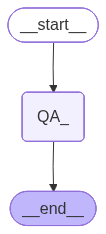

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
initial_state = {"question": "How far is Sun and Earth"}
final_state = workflow.invoke(initial_state)
print(final_state["answer"])

The **average distance** between the **Sun** and the **Earth** is approximately **149.6 million kilometers (93 million miles)**. This distance is known as an **astronomical unit (AU)**, which is a standard unit of measurement in astronomy.

### Key Details:
1. **Perihelion (Closest Approach)**:
   - Around **January 3**, the Earth is about **147.1 million km (91.4 million miles)** from the Sun.

2. **Aphelion (Farthest Distance)**:
   - Around **July 4**, the Earth is about **152.1 million km (94.5 million miles)** from the Sun.

3. **Light Travel Time**:
   - Sunlight takes about **8 minutes and 20 seconds** to reach Earth.

### Why Does the Distance Vary?
The Earth's orbit is **elliptical (not perfectly circular)**, causing slight variations in distance throughout the year. However, the average (1 AU) is the most commonly cited value.

Would you like details on how this distance is measured?
